# Design and Build a Mini Production ML System
## Dataset: Telco Customer Churn

**Use case:** Binary classification to identify customers at risk of churn.  
**Goal:** Demonstrate production ML concepts, reproducibility, serving, monitoring, and retraining rather than chase state-of-the-art accuracy.

## 1. Assessment Map
This notebook directly addresses: data description and non-trivial features; offline/online feature consistency; batch ingestion; repeatable training; baseline-vs-candidate evaluation; saved artifacts; FastAPI serving; latency measurement; drift/data-quality checks; retraining triggers; and incident response.

In [1]:
from pathlib import Path
import sys, json, time, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.features import build_features, split_xy
from src.ingest import ingest
from src.monitor import check
from src.retrain import should_retrain
pd.set_option("display.max_columns", 50)
print("Project root:", ROOT)

Project root: /mnt/data/mini_production_ml_system


## 2. Problem Definition and Success Metrics
Churn prediction supports proactive retention. Missing a true churner can be expensive, so **recall** matters; excessive false positives waste retention offers, so **precision** also matters. **ROC AUC** is the promotion metric because it measures ranking quality across thresholds. Accuracy and F1 are reported as supporting metrics. The operating threshold is initially 0.50 and should later be optimized using retention economics.

In [ ]:
df = pd.read_csv("C:/BITS Pilani/MLME/mini_production_ml_system/data/raw/telco_customer_churn.csv")
print("Shape:", df.shape)
display(df.head())
display(df.dtypes.to_frame("dtype"))
print("Target distribution:")
print(df["Churn"].value_counts(normalize=True).rename("proportion"))

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


,dtype
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


Target distribution:
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


### Cleaning assumptions
`TotalCharges` contains blank strings, so it is converted to numeric. Missing values are imputed using `MonthlyCharges × tenure`, a transparent approximation. `customerID` is excluded from modeling because it is an identifier. The split is stratified and uses a fixed random seed.

In [3]:
featured = build_features(df)
new_features = ["avg_charge_per_month","charge_gap","service_count","security_support_count","streaming_count","is_new_customer","monthly_charge_per_service","automatic_payment","contract_risk_score"]
display(featured[new_features].head())
print(featured[new_features].describe().T)

,avg_charge_per_month,charge_gap,service_count,security_support_count,streaming_count,is_new_customer,monthly_charge_per_service,automatic_payment,contract_risk_score
0,29.850000,0.00,1,1,0,1,29.850000,0,2
1,55.573529,-46.80,3,2,0,0,18.983333,0,1
2,54.075000,0.45,3,2,0,1,17.950000,0,2
3,40.905556,-62.75,3,3,0,0,14.100000,1,1
4,75.825000,10.25,1,0,0,1,70.700000,0,2


                             count       mean        std         min     25%  \
avg_charge_per_month        7043.0  64.698218  30.270670    0.000000  35.649   
charge_gap                  7043.0   0.152953  67.202778 -370.850000 -28.600   
service_count               7043.0   3.362914   2.062031    0.000000   1.000   
security_support_count      7043.0   1.265654   1.286879    0.000000   0.000   
streaming_count             7043.0   0.772256   0.852573    0.000000   0.000   
is_new_customer             7043.0   0.210280   0.407536    0.000000   0.000   
monthly_charge_per_service  7043.0  22.509972  11.576218   10.416667  15.700   
automatic_payment           7043.0   0.435326   0.495835    0.000000   0.000   
contract_risk_score         7043.0   1.309527   0.833755    0.000000   1.000   

                              50%        75%     max  
avg_charge_per_month        70.30  90.174158  121.40  
charge_gap                   0.00  28.500000  373.25  
service_count                3.00 

## 3. Feature Design and Training–Serving Consistency
The engineered features capture customer economics, product depth, protection/support coverage, streaming behavior, early-tenure risk, payment automation, and contract commitment. They are **online-computable** from the request payload. In production, historical aggregates would be stored in a feature table and refreshed in batch. Training-serving skew is reduced by importing the same deterministic `build_features()` function in both the training pipeline and FastAPI service. The fitted sklearn pipeline also stores imputation, scaling, and one-hot encoding with the model.

## 4. Batch Data Ingestion
The ingestion script reads a new CSV, merges it into the training table by `customerID`, keeps the latest record, and writes a JSONL audit log with timestamp and row counts. This makes repeated runs idempotent.

In [ ]:
demo_out = "C:/BITS Pilani/MLME/mini_production_ml_system/data/processed/notebook_training_data.csv"
if demo_out.exists(): demo_out.unlink()
log = ingest(str("C:/BITS Pilani/MLME/mini_production_ml_system/data/raw/telco_customer_churn.csv"), str(demo_out))
log

{
  "timestamp_utc": "2026-08-01T14:32:46.262549+00:00",
  "source": "/mnt/data/mini_production_ml_system/data/raw/telco_customer_churn.csv",
  "rows_read": 7043,
  "rows_before": 0,
  "rows_after": 7043
}


{'timestamp_utc': '2026-08-01T14:32:46.262549+00:00',
 'source': '/mnt/data/mini_production_ml_system/data/raw/telco_customer_churn.csv',
 'rows_read': 7043,
 'rows_before': 0,
 'rows_after': 7043}

## 5. Repeatable Training and Offline Evaluation
The repository training pipeline follows `load → clean/features → stratified split → fit → evaluate → promotion decision → save model and reports`. The baseline is a prior-probability dummy classifier; the candidate is class-balanced logistic regression. Logistic regression is selected because it is fast, interpretable, stable, and suitable for low-latency online scoring.

In [ ]:
report = json.loads(("C:/BITS Pilani/MLME/mini_production_ml_system/artifacts/eval/evaluation_report.json").read_text())
pd.DataFrame({k:v for k,v in report.items() if k in ["baseline","candidate"]}).T[["accuracy","roc_auc","precision","recall","f1"]]

,accuracy,roc_auc,precision,recall,f1
baseline,0.734564,0.5,0.0,0.0,0.0
candidate,0.74379,0.84561,0.511188,0.794118,0.62199


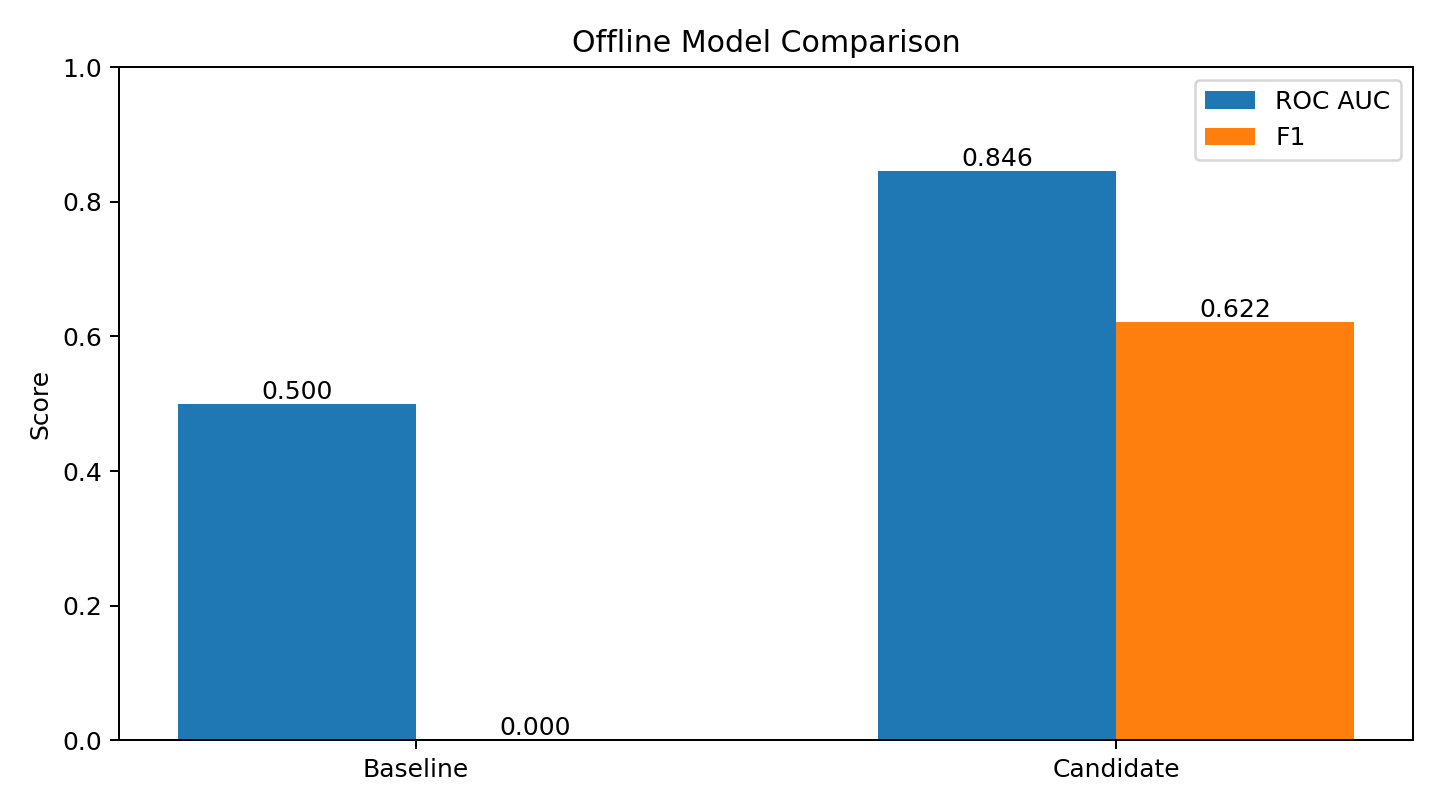

{
  "rule": "candidate_auc >= 0.80 and >= baseline_auc + 0.01",
  "promote": true,
  "model_version": "telco-churn-logreg-v1.0.0"
}


In [ ]:
display(Image(filename=str("C:/BITS Pilan/MLME/mini_production_ml_system/artifacts/eval/model_comparison.png")))
print(json.dumps(report["promotion"], indent=2))

### Promotion decision
The candidate is promoted only when its ROC AUC is at least 0.80 and at least 0.01 higher than the baseline. This guardrail prevents accidental deployment of a weak model while keeping the rule understandable and reproducible.

## 6. Serving and Inference Pattern
The chosen pattern is an **online request–response API**. A retention agent or CRM workflow may require a churn score while a customer record is open; sub-second latency is therefore appropriate. `src/api.py` exposes `/health` and `/predict`. The response includes the class, probability, model version, and per-request latency. Batch scoring remains possible by applying the same saved pipeline to a CSV.

In [ ]:
model = joblib.load("C:/BITS Pilani/MLME/mini_production_ml_system/models/churn_model.joblib")
sample = df.drop(columns=["Churn","customerID"]).iloc[[0]]
X_sample = build_features(sample).drop(columns=["Churn","customerID"], errors="ignore")
prob = float(model.predict_proba(X_sample)[:,1][0])
{"prediction": int(prob>=0.5), "label": "Yes" if prob>=0.5 else "No", "churn_probability": round(prob,6), "model_version": report["promotion"]["model_version"]}

{'prediction': 1,
 'label': 'Yes',
 'churn_probability': 0.829959,
 'model_version': 'telco-churn-logreg-v1.0.0'}

In [ ]:
latency = json.loads(("C:/BITS Pilani/MLME/mini_production_ml_system/artifacts/eval/latency_report.json").read_text())
latency

{'requests': 500,
 'avg_latency_ms': 2.7572072800004435,
 'p95_latency_ms': 3.073179299974526,
 'throughput_rows_per_sec': 362.685826072474}

## 7. Monitoring and Data Quality
The operational dashboard should serve three audiences: platform engineers (latency, p95, throughput, error rate), data/ML engineers (row counts, schema, nulls, ranges, feature drift), and product/retention owners (score distribution, contact rate, save rate, and delayed precision/recall/AUC when labels arrive). Alerts should be severity-based and routed to the responsible owner.

In [ ]:
monitoring = check(str("C:/BITS Pilani/MLME/mini_production_ml_system/data/raw/telco_customer_churn.csv"), str("C:/BITS Pilani/MLME/mini_production_ml_system/data/processed/recent_batch.csv"))
monitoring

{
  "rows": 700,
  "max_null_rate": 0.0,
  "drift_scores": {
    "MonthlyCharges": 0.009391585621644088,
    "tenure": 0.011214991565079109
  },
  "status": "PASS",
  "warnings": []
}


{'rows': 700,
 'max_null_rate': 0.0,
 'drift_scores': {'MonthlyCharges': 0.009391585621644088,
  'tenure': 0.011214991565079109},
 'status': 'PASS',
 'warnings': []}

The lightweight check validates required columns, null rates, tenure range, and standardized mean shifts for `MonthlyCharges` and `tenure`. A warning is logged if the absolute drift score exceeds 0.25 standard deviations.

## 8. Retraining Trigger Logic

In [10]:
decision, signals = should_retrain(new_days=31, recent_auc=0.79, drift_score=0.18, baseline_auc=0.84)
{"should_retrain": decision, "signals": signals}

{'should_retrain': True,
 'signals': {'enough_new_data': True,
  'performance_drop': True,
  'material_drift': False}}

Retraining is triggered when any of three conditions holds: at least 30 days of new data are available; recent labeled AUC falls more than 0.03 below the reference; or a drift score exceeds 0.25. A production workflow would validate the candidate, run fairness and regression checks, register it, canary deploy it, and retain the previous version for rollback.

## 9. Incident Scenario
**Scenario:** an upstream billing-system change renames `MonthlyCharges` and sends it as formatted text. Schema monitoring detects the missing expected field; validation failures increase the API error rate; the feature dashboard shows a sudden null spike. The response is to stop promotion/retraining, route traffic to the previous model or a safe fallback, quarantine the bad batch, correct the schema mapping, backfill affected data, rerun validation and evaluation, and only then restore normal scoring.

## 10. Architecture

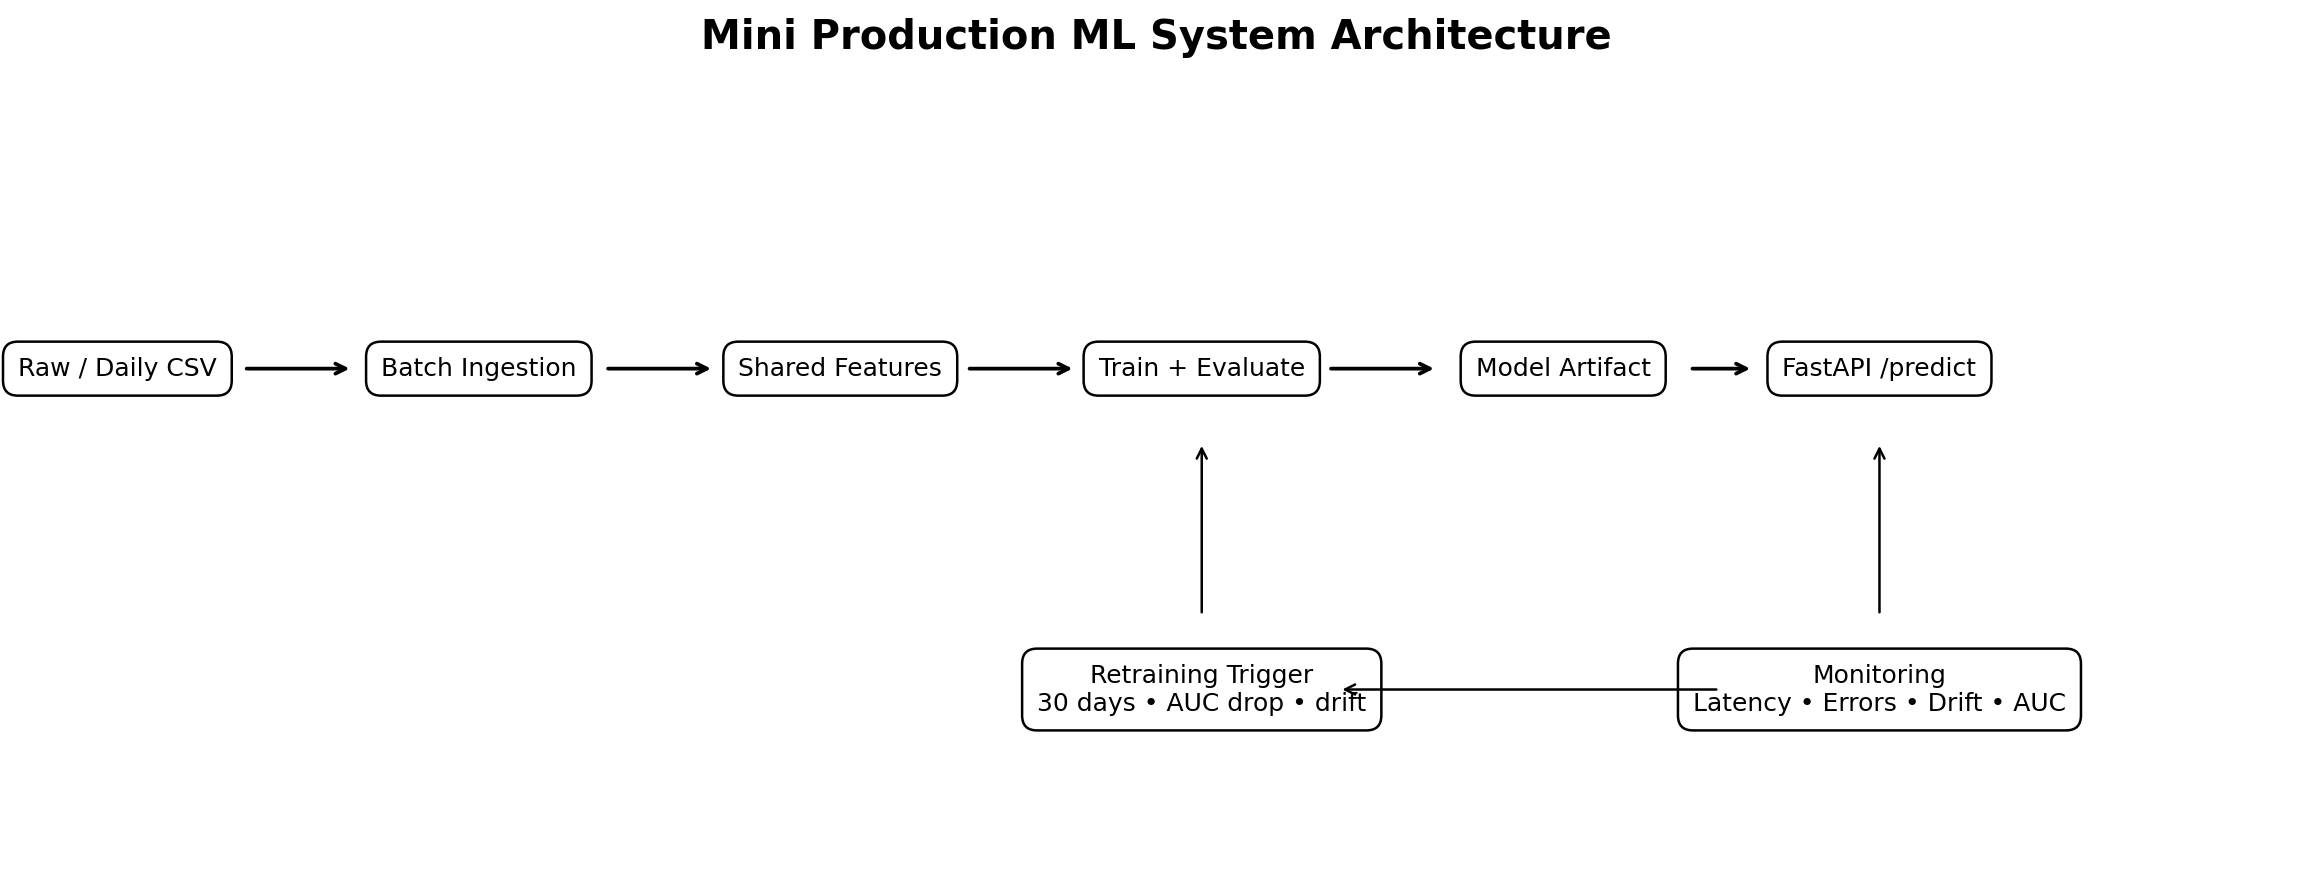

In [ ]:
display(Image(filename=str("C:/BITS Pilani/MLME/mini_production_ml_system/artifacts/architecture_diagram.png")))

## 11. Trade-offs, Limitations, and Future Work
The current model favors simplicity and operational reliability over maximum accuracy. The dataset is a static snapshot with no event timestamps, so true time-based validation and delayed-label monitoring cannot be demonstrated. The default 0.50 threshold is not cost-optimized, and no causal claim is made about why customers churn. Future work should add time-aware splits, calibration, threshold optimization using retention value, fairness checks, model registry/versioning, containerization, CI/CD, authenticated APIs, feature-store integration, canary deployment, and champion–challenger retraining.